[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benchmark-urbanism/cityseer-examples/blob/gh-pages/recipes/centrality/3d_elevation.ipynb)


# Elevation effects on centrality

::: {.callout-important}
3D elevation support requires cityseer **v4.24.0** or later.
:::

Compare centrality results with and without Z coordinates (elevation). When nodes have `z` attributes, cityseer automatically applies **Tobler's hiking function** during pathfinding — uphill segments become costlier and gentle downhill segments become slightly cheaper. This reshapes which paths are "shortest" and therefore changes centrality values.


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import shapely
from cityseer.metrics import networks
from cityseer.tools import graphs, io
from scipy.stats import spearmanr

## Load the road network

Load a hilly subset of Madrid's road network with real 3D geometries (Sierra de Guadarrama foothills). The dataset is loaded twice: once preserving the Z coordinates (hilly) and once stripping them (flat).


In [ ]:
import copy

edges_raw = gpd.read_file("data/madrid_streets/street_network_3d.gpkg")
edges_raw = edges_raw.explode(index_parts=False)
print(f"Loaded {len(edges_raw)} edges, has_z={edges_raw.geometry.iloc[0].has_z}")

# Build primal graph once (with Z), then simplify
G_primal = io.nx_from_generic_geopandas(edges_raw)
G_primal = graphs.nx_remove_filler_nodes(G_primal)
G_primal = graphs.nx_remove_dangling_nodes(G_primal)

# Report elevation range
zs = [d["z"] for _, d in G_primal.nodes(data=True) if "z" in d]
print(
    f"Elevation range: {min(zs):.0f}m – {max(zs):.0f}m (spread: {max(zs) - min(zs):.0f}m)"
)

# HILLY dual — preserves Z
G_hilly = graphs.nx_to_dual(G_primal)

# FLAT dual — strip Z from a copy of the same primal graph
G_flat_primal = copy.deepcopy(G_primal)
for node_idx, node_data in G_flat_primal.nodes(data=True):
    node_data.pop("z", None)
for u, v, edge_data in G_flat_primal.edges(data=True):
    if "geom" in edge_data:
        edge_data["geom"] = shapely.force_2d(edge_data["geom"])
G_flat = graphs.nx_to_dual(G_flat_primal)

INFO:cityseer.tools.graphs:Merging parallel edges within buffer of 1.


Loaded 1492 edges, has_z=True


INFO:cityseer.tools.graphs:Removing filler nodes.
INFO:cityseer.tools.graphs:Removing dangling nodes.
INFO:cityseer.tools.graphs:Removing filler nodes.
INFO:cityseer.tools.graphs:Converting graph to dual.
INFO:cityseer.tools.graphs:Preparing dual nodes
INFO:cityseer.tools.graphs:Preparing dual edges (splitting and welding geoms)


Elevation range: 945m – 1706m (spread: 761m)


INFO:cityseer.tools.graphs:Converting graph to dual.
INFO:cityseer.tools.graphs:Preparing dual nodes
INFO:cityseer.tools.graphs:Preparing dual edges (splitting and welding geoms)


## Elevation profile

Visualise the terrain elevation across the network using contours interpolated from the node Z values.


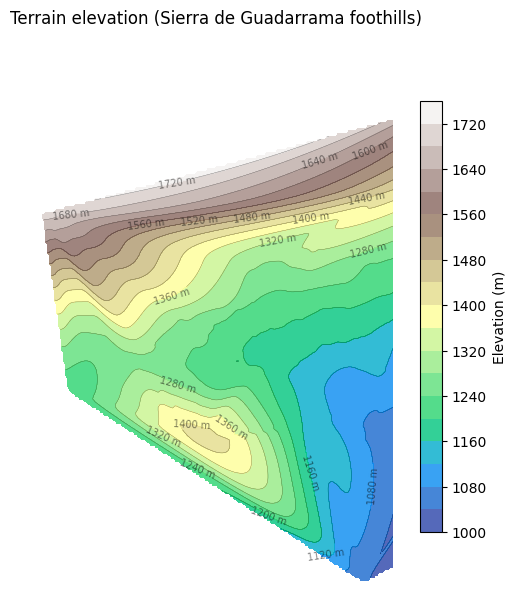

In [ ]:
from scipy.interpolate import griddata

# Extract node positions and elevations from primal graph
xs = np.array([d["x"] for _, d in G_primal.nodes(data=True)])
ys = np.array([d["y"] for _, d in G_primal.nodes(data=True)])
zs = np.array([d["z"] for _, d in G_primal.nodes(data=True)])

# Create grid and interpolate
xlim = (437400, 442200)
ylim = (4519850, 4527150)
grid_x, grid_y = np.mgrid[xlim[0] : xlim[1] : 200j, ylim[0] : ylim[1] : 200j]
grid_z = griddata((xs, ys), zs, (grid_x, grid_y), method="cubic")

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
contour_filled = ax.contourf(
    grid_x, grid_y, grid_z, levels=20, cmap="terrain", alpha=0.8
)
contour_lines = ax.contour(
    grid_x, grid_y, grid_z, levels=20, colors="k", linewidths=0.3, alpha=0.5
)
ax.clabel(contour_lines, inline=True, fontsize=7, fmt="%.0f m")
plt.colorbar(contour_filled, ax=ax, label="Elevation (m)", shrink=0.8)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect("equal")
ax.set_title("Terrain elevation (Sierra de Guadarrama foothills)")
ax.axis(False)
plt.show()

## Compute centrality — flat vs hilly

Run shortest-path closeness and betweenness at a 1000m threshold for both versions. Use [`network_structure_from_nx`](https://cityseer.benchmarkurbanism.com/tools/io#network-structure-from-nx) to prepare the data structures and [`node_centrality_simplest`](https://cityseer.benchmarkurbanism.com/metrics/networks#node-centrality-simplest) to compute the centralities.


In [4]:
distances = [1000]

# Flat
nodes_flat, _edges_flat, net_flat = io.network_structure_from_nx(G_flat)
nodes_flat = networks.node_centrality_simplest(
    network_structure=net_flat,
    nodes_gdf=nodes_flat,
    distances=distances,
    compute_closeness=True,
    compute_betweenness=True,
)

# Hilly
nodes_hilly, _edges_hilly, net_hilly = io.network_structure_from_nx(G_hilly)
nodes_hilly = networks.node_centrality_simplest(
    network_structure=net_hilly,
    nodes_gdf=nodes_hilly,
    distances=distances,
    compute_closeness=True,
    compute_betweenness=True,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
INFO:cityseer.graph:Edge R-tree built successfully with 2301 items.
INFO:cityseer.metrics.networks:Computing node centrality (simplest).
INFO:cityseer.metrics.networks:  Full: 1000m
INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
INFO:cityseer.graph:Edge R-tree built successfully with 2301 items.
INFO:cityseer.metrics.networks:Computing node centrality (simplest).
INFO:cityseer.metrics.networks:  Full: 1000m


## Compare results

Align nodes by position and visualise the flat vs hilly centrality results side by side, along with the difference.


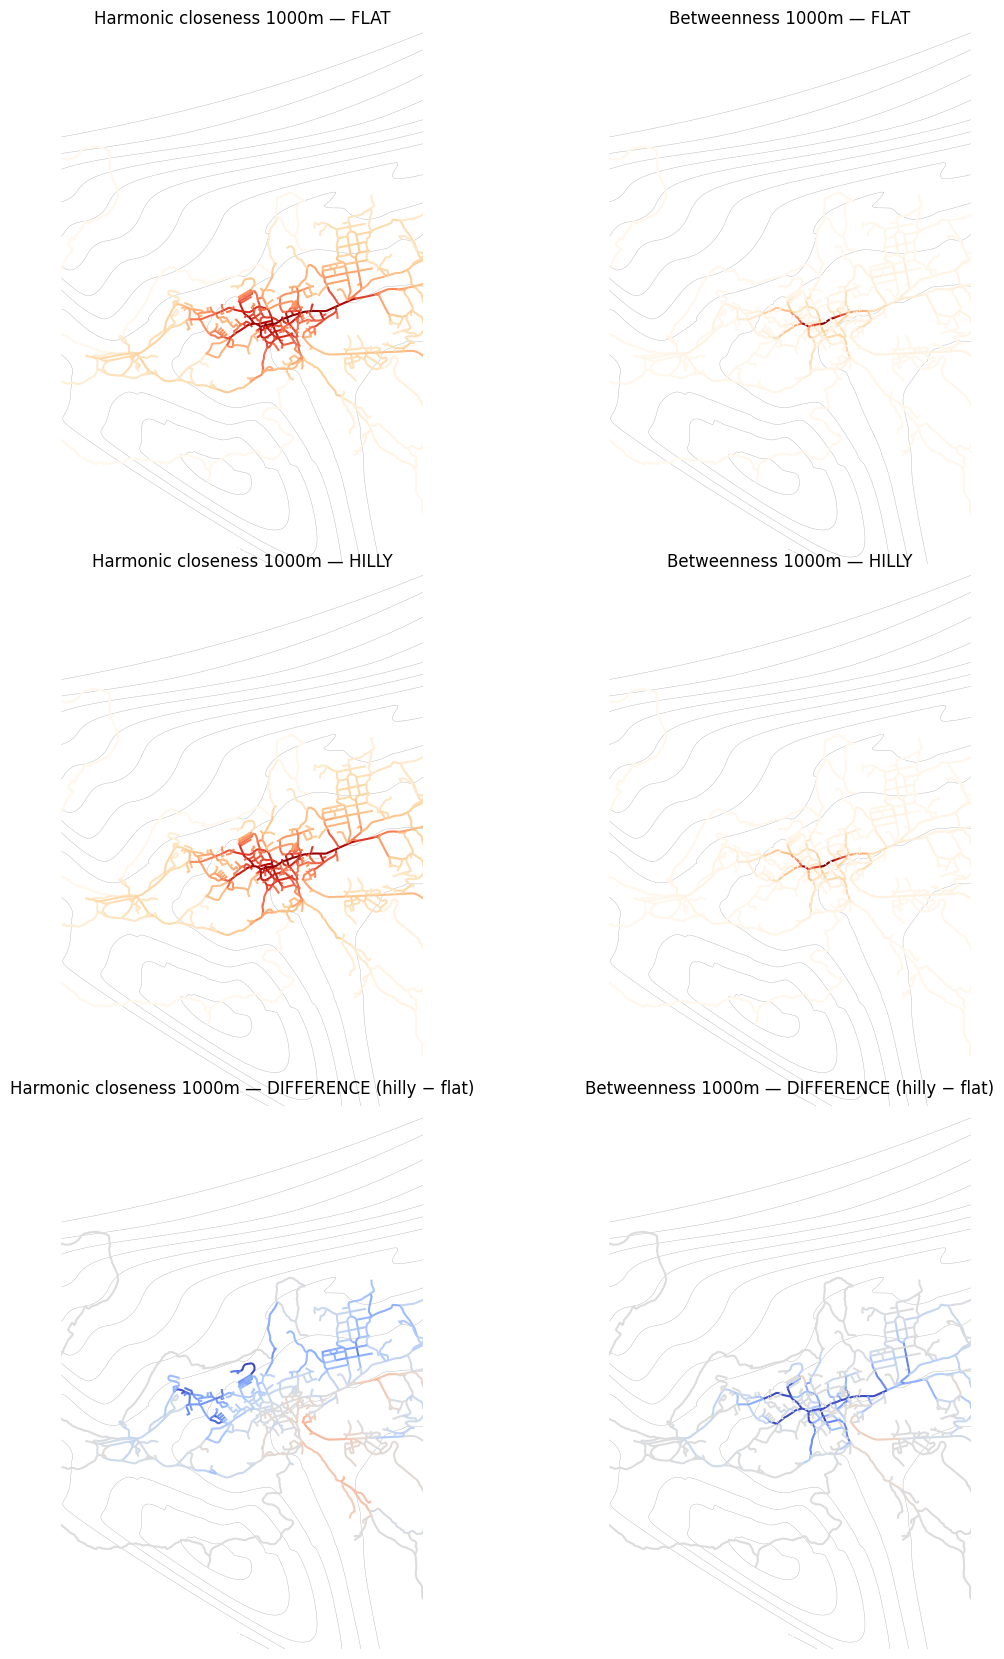

In [8]:
from scipy.interpolate import griddata

d = 1000
harm_key = f"cc_harmonic_{d}_ang"
betw_key = f"cc_betweenness_{d}_ang"

# Same topology so indices align directly
diff_gdf = nodes_flat.copy()
diff_gdf["harm_diff"] = nodes_hilly[harm_key].values - nodes_flat[harm_key].values
diff_gdf["betw_diff"] = nodes_hilly[betw_key].values - nodes_flat[betw_key].values

# Zoom extent
xlim = (438200, 441600)
ylim = (4521000, 4526000)
lw = 1.5

# Prepare elevation contour grid
xs = np.array([nd["x"] for _, nd in G_primal.nodes(data=True)])
ys = np.array([nd["y"] for _, nd in G_primal.nodes(data=True)])
zs = np.array([nd["z"] for _, nd in G_primal.nodes(data=True)])
grid_x, grid_y = np.mgrid[xlim[0] : xlim[1] : 200j, ylim[0] : ylim[1] : 200j]
grid_z = griddata((xs, ys), zs, (grid_x, grid_y), method="cubic")

fig, axes = plt.subplots(
    3, 2, figsize=(14, 21), gridspec_kw={"hspace": 0.02, "wspace": 0.02}
)

for ax in axes.flat:
    ax.contour(grid_x, grid_y, grid_z, levels=15, colors="k", linewidths=0.3, alpha=0.3)

# Row 1: Flat
nodes_flat.plot(ax=axes[0, 0], column=harm_key, cmap="OrRd", linewidth=lw, legend=False)
axes[0, 0].set_title(f"Harmonic closeness {d}m — FLAT")
axes[0, 0].set_xlim(xlim)
axes[0, 0].set_ylim(ylim)
axes[0, 0].set_aspect("equal")
axes[0, 0].axis(False)

nodes_flat.plot(ax=axes[0, 1], column=betw_key, cmap="OrRd", linewidth=lw, legend=False)
axes[0, 1].set_title(f"Betweenness {d}m — FLAT")
axes[0, 1].set_xlim(xlim)
axes[0, 1].set_ylim(ylim)
axes[0, 1].set_aspect("equal")
axes[0, 1].axis(False)

# Row 2: Hilly
nodes_hilly.plot(
    ax=axes[1, 0], column=harm_key, cmap="OrRd", linewidth=lw, legend=False
)
axes[1, 0].set_title(f"Harmonic closeness {d}m — HILLY")
axes[1, 0].set_xlim(xlim)
axes[1, 0].set_ylim(ylim)
axes[1, 0].set_aspect("equal")
axes[1, 0].axis(False)

nodes_hilly.plot(
    ax=axes[1, 1], column=betw_key, cmap="OrRd", linewidth=lw, legend=False
)
axes[1, 1].set_title(f"Betweenness {d}m — HILLY")
axes[1, 1].set_xlim(xlim)
axes[1, 1].set_ylim(ylim)
axes[1, 1].set_aspect("equal")
axes[1, 1].axis(False)

# Row 3: Difference (coolwarm, symmetric around zero)
vmax_h = np.abs(diff_gdf["harm_diff"]).max()
diff_gdf.plot(
    ax=axes[2, 0],
    column="harm_diff",
    cmap="coolwarm",
    linewidth=lw,
    legend=False,
    vmin=-vmax_h,
    vmax=vmax_h,
)
axes[2, 0].set_title(f"Harmonic closeness {d}m — DIFFERENCE (hilly − flat)")
axes[2, 0].set_xlim(xlim)
axes[2, 0].set_ylim(ylim)
axes[2, 0].set_aspect("equal")
axes[2, 0].axis(False)

vmax_b = np.abs(diff_gdf["betw_diff"]).max() / 4
diff_gdf.plot(
    ax=axes[2, 1],
    column="betw_diff",
    cmap="coolwarm",
    linewidth=lw,
    legend=False,
    vmin=-vmax_b,
    vmax=vmax_b,
)
axes[2, 1].set_title(f"Betweenness {d}m — DIFFERENCE (hilly − flat)")
axes[2, 1].set_xlim(xlim)
axes[2, 1].set_ylim(ylim)
axes[2, 1].set_aspect("equal")
axes[2, 1].axis(False)

plt.show()

## Rank correlation

Compute Spearman rank correlations and mean percentage changes to quantify how much elevation affects the centrality rankings.


In [ ]:
print(f"{'Metric':<35} {'Spearman ρ':>10} {'Mean % change':>15}")
print("-" * 65)

for metric, label in [
    ("harmonic", "Angular harmonic closeness"),
    ("betweenness", "Angular betweenness"),
]:
    key = f"cc_{metric}_{d}_ang"
    flat_vals = nodes_flat[key].values
    hilly_vals = nodes_hilly[key].values

    mask = (flat_vals > 0) & (hilly_vals > 0)
    rho, _ = spearmanr(flat_vals[mask], hilly_vals[mask])
    pct_change = (
        np.mean(np.abs(hilly_vals[mask] - flat_vals[mask]) / flat_vals[mask]) * 100
    )

    print(f"{label} {d}m{'':<5} {rho:>10.4f} {pct_change:>14.1f}%")

Metric                              Spearman ρ   Mean % change
-----------------------------------------------------------------
Angular harmonic closeness 1000m          0.9946            6.2%
Angular betweenness 1000m          0.9981            9.3%


## Summary

This notebook demonstrated how **elevation (Z coordinates)** affects centrality results. When 3D geometries are present, cityseer automatically applies Tobler's hiking function, which penalises uphill travel and slightly rewards gentle downhill slopes. The effect is asymmetric — walking uphill costs more than walking downhill — which shifts betweenness patterns in hilly terrain.

**Next steps:**

- To calculate angular centralities without elevation, see [Angular Centrality](gpd_angular_centrality.ipynb).
- To calculate metric (shortest-path) centralities, see [Metric Centrality](gpd_metric_centrality.ipynb).
- To compute centralities directly from OpenStreetMap data, see [OSM Centrality](osm_centrality.ipynb).
